---
## This script will do some analysis/stats about concurrent events for R2Q2 
#### Might be making a supplemental figure (S2)...
##### Noel Siegert, 6/24/26
---

In [1]:
# kernel: pangeo23

In [2]:
# imports
import os
import xarray as xr
import numpy as np
import netCDF4 
import glob
import pandas as pd
import geopandas as gpd
from datetime import datetime
from scipy import stats

from coastal_analysis_fns import *

In [3]:
# interactive plotting stuff 
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import colors
import matplotlib.cm as cm
import matplotlib.gridspec as gridspec
from matplotlib import rcParams
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from matplotlib.lines import Line2D 

#import matplotlib.dates as mdates
%matplotlib inline
plt.rcParams['figure.figsize'] = 12, 6
#%config InlineBackend.figure_format = 'retina'

import cartopy
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point
import seaborn as sns

In [4]:
script = 'FigSx_resubmissionJun26_ConcurrentEvStats.ipynb'

In [5]:
# dataframe with the stations we are using
df = pd.read_csv('/home/nsiegert/projects/coastal_sst/data/hadisd_stations_using_Expanded.csv')
df = df.drop(['Unnamed: 0'], axis=1)

# convert df into geodataframe for ease of plotting
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(x=df.LON, y=df.LAT))

In [6]:
# open hw data

# MHW
hw_ds = xr.open_dataset('/dx02/data/nsiegert/coastal_mhw_data/ALLSTATIONS.1.5deg.marineheatwaves_roll11.nc') # 11 DAY ROLLING!!!
mhw_mask = hw_ds.MHW
mhw_onset_mask = hw_ds.MHW_onsets.astype(bool)

# thw
thw_ds = xr.open_dataset('/dx02/data/nsiegert/coastal_mhw_data/ALLSTATIONS.1.5deg.heatwaves.nc')
thw_mask = thw_ds.THW
thw_onset_mask = thw_ds.THW_onsets.astype(bool)

# season masks
szn_ds = xr.open_dataset('/dx02/data/nsiegert/coastal_mhw_data/ALLSTATIONS.warm_cold_seasons.nc')
warmszn_mask = szn_ds.warmszn_mask.astype(bool)
coldszn_mask = szn_ds.coldszn_mask.astype(bool)

In [7]:
## Generate concurrent event days and onsets

# concurrent MHW-THW days
con_mhwthwdays = hw_ds.MHW * thw_ds.THW

# gen standalone DAYS 
mhw_standalone_mask = (mhw_mask * np.logical_not(thw_mask))
thw_standalone_mask = (thw_mask * np.logical_not(mhw_mask))

# gather concurrent event onsets
concurrent_ev_mask = (mhw_mask * thw_mask)

# onsets are days where there is no concurrent event (=0), and the next day = 1
concurrent_ev_onsetmaskPre = (concurrent_ev_mask==0).data[:, :-1] * concurrent_ev_mask.data[:, 1:] # and have to drop the last day of ds from analysis. This gets us an onset mask for the second day of the ds onwards. 
concurrent_ev_onsetmask = np.zeros(shape=concurrent_ev_mask.shape)
concurrent_ev_onsetmask[:, 1:] = concurrent_ev_onsetmaskPre # fill in the 0 on the first day0 (which can't be an onset b/c we don't know the status of the day prior)

concurrent_ev_onsetmask_da = xr.DataArray(concurrent_ev_onsetmask, dims=concurrent_ev_mask.dims, coords=concurrent_ev_mask.coords)

## what is the average duration of a concurrent event, at each station (or I could do a histogram or something)

In [8]:
### Generate average event durations for all 3 types of events?

ev_masks = [mhw_mask, thw_mask, concurrent_ev_mask] # replace this - used to do "standalone" mask
ev_onsets = [mhw_onset_mask, thw_onset_mask, concurrent_ev_onsetmask_da]

str_template = 'avg_EEE_durationsSSS'

for evctr, ev_type in enumerate(['mhw', 'thw', 'con']):

    evmask = ev_masks[evctr]
    evonsets = ev_onsets[evctr]

    # compute average event durations at each station
    avg_ev_durations_per_station = (evmask.sum(dim='time') / evonsets.sum(dim='time'))
    avg_ev_durations_per_station_w = (evmask.where(warmszn_mask).sum(dim='time') / evonsets.where(warmszn_mask).sum(dim='time'))
    avg_ev_durations_per_station_c = (evmask.where(coldszn_mask).sum(dim='time') / evonsets.where(coldszn_mask).sum(dim='time'))

    # add to gdf, for plotting. 
    gdf[str_template.replace('EEE', ev_type).replace('SSS', '')] = avg_ev_durations_per_station
    gdf[str_template.replace('EEE', ev_type).replace('SSS', '_w')] = avg_ev_durations_per_station_w
    gdf[str_template.replace('EEE', ev_type).replace('SSS', '_c')] = avg_ev_durations_per_station_c

    # gen lat-profiles as well 
    durations_binned, bin_midpoints, bin_nobs = bin_lat_scatters(latbins=np.arange(-60, 71, 3), lats=gdf['LAT'].to_numpy(), dat=gdf[str_template.replace('EEE', ev_type).replace('SSS', '')].to_numpy())
    durations_binned_w, bin_midpoints, bin_nobs = bin_lat_scatters(latbins=np.arange(-60, 71, 3), lats=gdf['LAT'].to_numpy(), dat=gdf[str_template.replace('EEE', ev_type).replace('SSS', '_w')].to_numpy())
    durations_binned_c, bin_midpoints, bin_nobs = bin_lat_scatters(latbins=np.arange(-60, 71, 3), lats=gdf['LAT'].to_numpy(), dat=gdf[str_template.replace('EEE', ev_type).replace('SSS', '_c')].to_numpy())

/home/nsiegert/projects/coastal_sst/code/analysis/coastal_analysis_fns.py:53: RuntimeWarning: Mean of empty slice
  binned_means.append(np.nanmean(dat[binmask*no_inf_mask]))
/home/nsiegert/projects/coastal_sst/code/analysis/coastal_analysis_fns.py:53: RuntimeWarning: Mean of empty slice
  binned_means.append(np.nanmean(dat[binmask*no_inf_mask]))
/home/nsiegert/projects/coastal_sst/code/analysis/coastal_analysis_fns.py:53: RuntimeWarning: Mean of empty slice
  binned_means.append(np.nanmean(dat[binmask*no_inf_mask]))


In [9]:
# station-by-station map of average concurrent event durations, using the non-restrictive definition

avg_con_durations_per_station = (con_mhwthwdays.sum(dim='time') / concurrent_ev_onsetmask_da.sum(dim='time'))
gdf['avg_con_durations_per_station'] = avg_con_durations_per_station

In [10]:
# make some binned lat things
con_durations_binned, bin_midpoints, bin_nobs = bin_lat_scatters(latbins=np.arange(-60, 71, 3), lats=gdf['LAT'].to_numpy(), dat=gdf['avg_con_durations'].to_numpy())
mhw_durations_binned, bin_midpoints, bin_nobs = bin_lat_scatters(latbins=np.arange(-60, 71, 3), lats=gdf['LAT'].to_numpy(), dat=gdf['avg_mhw_durations'].to_numpy())
thw_durations_binned, bin_midpoints, bin_nobs = bin_lat_scatters(latbins=np.arange(-60, 71, 3), lats=gdf['LAT'].to_numpy(), dat=gdf['avg_thw_durations'].to_numpy())

/home/nsiegert/projects/coastal_sst/code/analysis/coastal_analysis_fns.py:53: RuntimeWarning: Mean of empty slice
  binned_means.append(np.nanmean(dat[binmask*no_inf_mask]))


In [11]:
vmin = 2
vmax = 6
ncol = 9
bounds = np.linspace(vmin, vmax, ncol)
cols = plt.get_cmap('viridis')(np.linspace(0,1,len(bounds)+1))
cmap = colors.ListedColormap(cols[1:-1])
cmap.set_over(cols[-1])
cmap.set_under(cols[0])
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

cmap_c, norm_c, bounds_c = cmap, norm, bounds

bounds

array([2. , 2.5, 3. , 3.5, 4. , 4.5, 5. , 5.5, 6. ])

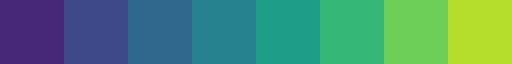

In [12]:
cmap

In [13]:
# gen colormap
vmin = 2
vmax = 6
ncol = 9
bounds = np.linspace(vmin, vmax, ncol)
cols = plt.get_cmap('viridis')(np.linspace(0,1,len(bounds)+1))
cmap = colors.ListedColormap(cols[1:-1])
cmap.set_over(cols[-1])
cmap.set_under(cols[0])
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

cmap_c, norm_c, bounds_c = cmap, norm, bounds

bounds

array([2. , 2.5, 3. , 3.5, 4. , 4.5, 5. , 5.5, 6. ])

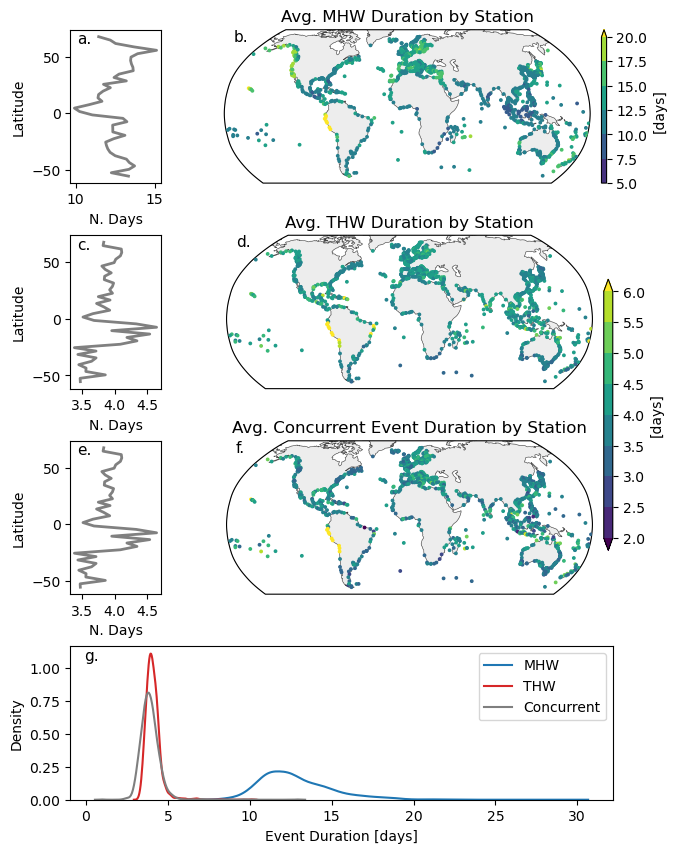

Event Duration maps


In [14]:
## nice plot of all 3

vmin = 2
vmax = 6
ncol = 9
bounds = np.linspace(vmin, vmax, ncol)
cols = plt.get_cmap('viridis')(np.linspace(0,1,len(bounds)+1))
cmap = colors.ListedColormap(cols[1:-1])
cmap.set_over(cols[-1])
cmap.set_under(cols[0])
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

cmap_c, norm_c, bounds_c = cmap, norm, bounds

vmin = 5
vmax = 20
ncol = 7
bounds = np.linspace(vmin, vmax, ncol)
cols = plt.get_cmap('viridis')(np.linspace(0,1,len(bounds)+1))
cmap = colors.ListedColormap(cols[1:-1])
cmap.set_over(cols[-1])
cmap.set_under(cols[0])
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

cmap_mhw, norm_mhw, bounds_mhw = cmap, norm, bounds


# setup axes
nrows = 4
ncols = 2
fig = plt.figure(figsize=(7, 10))
gs = gridspec.GridSpec(nrows=nrows, ncols=ncols, figure=fig, width_ratios=[1, 5]) 
gs.update(wspace=0., hspace=0.34)


## Plot data
ax0 = fig.add_subplot(gs[0,0])
ax1 = fig.add_subplot(gs[0,1], projection=ccrs.Robinson())

# ax 0 - mean duration of MHW events by latitude
ax0.plot(mhw_durations_binned, bin_midpoints, color='grey', lw=2, label='warm season')
ax0.set(ylabel='Latitude', xlabel='N. Days')

# ax 1 - avg MHW duration characteristics
gdf.plot(column='avg_mhw_durations', ax=ax1, cmap=cmap_mhw, norm=norm_mhw, transform=ccrs.PlateCarree(), markersize=3, zorder=10)
ax1.add_feature(cartopy.feature.LAND,edgecolor='black',facecolor='gainsboro',linewidth=0.4, alpha=0.5, zorder=0) 
ax1.add_feature(cartopy.feature.OCEAN,edgecolor='black',facecolor='white',linewidth=0.4, alpha=0.5, zorder=0) 
ax1.set(title='Avg. MHW Duration by Station')


ax2 = fig.add_subplot(gs[1,0])
ax3 = fig.add_subplot(gs[1,1], projection=ccrs.Robinson())

# ax 2 - mean duration of THW events by latitude
ax2.plot(con_durations_binned, bin_midpoints, color='grey', lw=2, label='warm season')
ax2.set(ylabel='Latitude', xlabel='N. Days')

# ax 3 - avg THW duration characteristics
gdf.plot(column='avg_thw_durations', ax=ax3, cmap=cmap_c, norm=norm_c, transform=ccrs.PlateCarree(), markersize=3, zorder=10)
ax3.add_feature(cartopy.feature.LAND,edgecolor='black',facecolor='gainsboro',linewidth=0.4, alpha=0.5, zorder=0) 
ax3.add_feature(cartopy.feature.OCEAN,edgecolor='black',facecolor='white',linewidth=0.4, alpha=0.5, zorder=0) 
ax3.set(title='Avg. THW Duration by Station')


ax4 = fig.add_subplot(gs[2,0])
ax5 = fig.add_subplot(gs[2,1], projection=ccrs.Robinson())

# ax 4 - mean duration of concurrent events by latitude
ax4.plot(con_durations_binned, bin_midpoints, color='grey', lw=2, label='warm season')
ax4.set(ylabel='Latitude', xlabel='N. Days')

# ax 5 - avg duration characteristics
gdf.plot(column='avg_con_durations', ax=ax5, cmap=cmap_c, norm=norm_c, transform=ccrs.PlateCarree(), markersize=3, zorder=10)
ax5.add_feature(cartopy.feature.LAND,edgecolor='black',facecolor='gainsboro',linewidth=0.4, alpha=0.5, zorder=0) 
ax5.add_feature(cartopy.feature.OCEAN,edgecolor='black',facecolor='white',linewidth=0.4, alpha=0.5, zorder=0) 
ax5.set(title='Avg. Concurrent Event Duration by Station')


## bottom ax: histogram
ax6 = fig.add_subplot(gs[3,:])
sns.kdeplot(gdf.avg_mhw_durations, label='MHW', ax=ax6, color='tab:blue')
sns.kdeplot(gdf.avg_thw_durations, label='THW', ax=ax6, color='tab:red')
sns.kdeplot(gdf.avg_con_durations, label='Concurrent', ax=ax6, color='tab:grey')
ax6.set(ylabel='Density', xlabel='Event Duration [days]')
ax6.legend()

ax0.text(s='a.', x=0.075, y=0.91, transform=ax0.transAxes, ha='left', fontsize=11)
ax1.text(s='b.', x=0.025, y=0.925, transform=ax1.transAxes, ha='left', fontsize=11)
ax2.text(s='c.', x=0.075, y=0.91, transform=ax2.transAxes, ha='left', fontsize=11)
ax3.text(s='d.', x=0.025, y=0.925, transform=ax3.transAxes, ha='left', fontsize=11)
ax4.text(s='e.', x=0.075, y=0.91, transform=ax4.transAxes, ha='left', fontsize=11)
ax5.text(s='f.', x=0.025, y=0.925, transform=ax5.transAxes, ha='left', fontsize=11)
ax6.text(s='g.', x=0.025, y=0.91, transform=ax6.transAxes, ha='left', fontsize=11)


# cbars
sm = plt.cm.ScalarMappable(norm=norm_mhw, cmap=cmap_mhw)
sm.set_array([])

cbar = fig.colorbar(sm,  
                    ax=ax1,
                    orientation="vertical",
                    extend='max',
                    label="[days]",
                    pad=0.025,
                    use_gridspec=True,
                    fraction=0.025, 
                    ticks=bounds_mhw,
                    aspect=30)


sm = plt.cm.ScalarMappable(norm=norm_c, cmap=cmap_c)
sm.set_array([])

cbar = fig.colorbar(sm,  
                    ax=[ax3, ax5],
                    orientation="vertical",
                    extend='both',
                    label="[days]",
                    pad=0.025,
                    use_gridspec=True,
                    fraction=0.02, 
                    ticks=bounds_c,
                    aspect=30)

plt.savefig('/home/nsiegert/projects/coastal_sst/plots/grl_resubmission_6.2026/FigSx_coastalsst_grl_6_26_averagedurations.png', format='png', bbox_inches='tight')

plt.show()

print('Event Duration maps')